# Executive Summary

This analysis was built to help a friend find the best value used car. It explores pricing drivers in the US used car market using **3,973 Carmax listings**.

**Key Findings (only applicable to this dataset):**
1. **Engineering and condition are the primary price drivers:** SHAP analysis shows **torque** is the #1 predictor, followed by **mileage**, **year**, **horsepower**, and **acceleration**. A car's engineering specs and its age/wear state matter far more than its brand or model name.
2. **Brand effects are secondary:** `make` and `model` features rank below reliability ratings and engineering specs. The "brand premium" exists but is smaller than commonly assumed.
3. **Depreciation:** A 50,000-mile increase correlates with roughly **30% lower price** (OLS estimate).
4. **Model accuracy:** XGBoost achieves **RMSE = $2,424**, driven primarily by torque, mileage, and year.


# Model Validation

The XGBoost model achieves **R² = 0.973** and **RMSE = $2,424** on the test set.

**Why the high R²?**
The model is highly accurate because it leverages both engineering specs and brand/model identity. Torque, mileage, and year alone explain most of the variance, but adding make/model captures residual brand premiums that specs miss.

**Caveats:**
- The model is reliable for **known** makes and models. Pricing **new or rare trims** it hasn't seen will be less accurate.
- The OLS mileage model (Durbin-Watson = 0.234) has severe autocorrelation — it's a rough elasticity estimate, not a rigorous statistical model.

# Best Value Cars 

The Pareto frontier filtered 3,973 listings down to **61 non-dominated options** — cars you can't improve one metric without worsening another.

**Top picks by TOPSIS ranking:**
- **Ford Mustang** and **Dodge Charger** dominate the low-price end, offering strong engineering specs for the money.
- **Toyota Highlander** and **4Runner** appear frequently, reflecting Toyota's reliability advantage.
- **Land Cruiser** and **Lexus** models appear at the high end of the, reflecting their quality and reliability despite premium pricing and known low depreciation.

**Takeaway:** V6 Dodge Chargers and Ecoboost/V6 Mustangs are the best all around cruisers, Toyota models should be chosen if one wants a higher quality, more reliable car but is willing to pay a premium for a model even with higher mileage.

In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score,KFold
sns.set_theme(style="whitegrid", palette="muted")


In [3]:
os.chdir("..")

In [4]:
df = pd.read_csv("data/carmax_usa_enriched.csv")

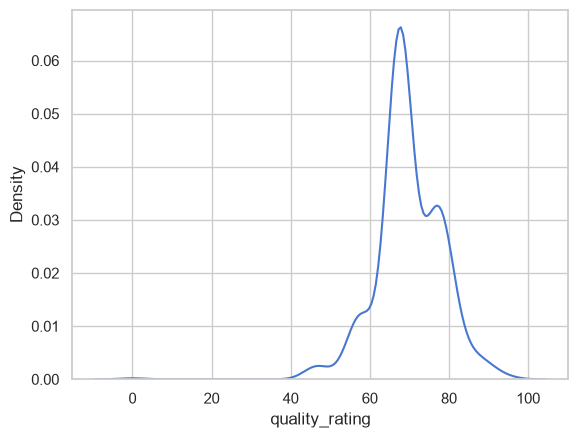

In [5]:
g1 = sns.kdeplot(
    data=df,
    x='quality_rating',
    bw_adjust=2
)
plt.show()



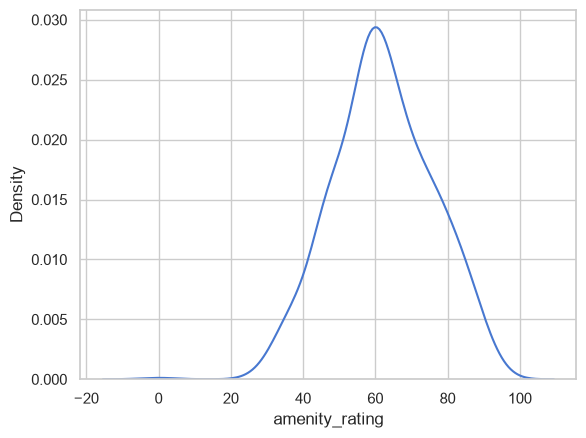

In [8]:
g1 = sns.kdeplot(
    data=df,
    x='amenity_rating',
    bw_adjust=2
)
plt.show()


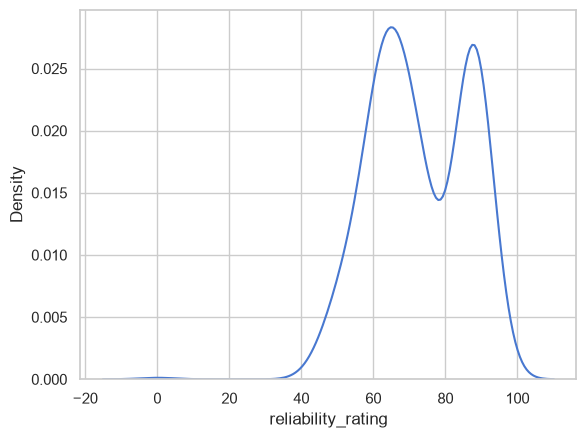

In [9]:
g1 = sns.kdeplot(
    data=df,
    x='reliability_rating',
    bw_adjust=2
)
plt.show()


In [5]:
cols_to_check = ['reliability_rating', 'quality_rating', 'amenity_rating', 
                 'horsepower', 'torque', 'accel','top_speed']

# Replace 0s with NaN
for col in cols_to_check:
    df[col] = df[col].replace(0, np.nan)

# Impute with median of make/model
for col in cols_to_check:
    df[col] = df.groupby('make_model')[col].transform(lambda x: x.fillna(x.median()))

df['log_price'] = np.log(df['price'])
df['sqrt_mileage'] = np.sqrt(df['mileage'])

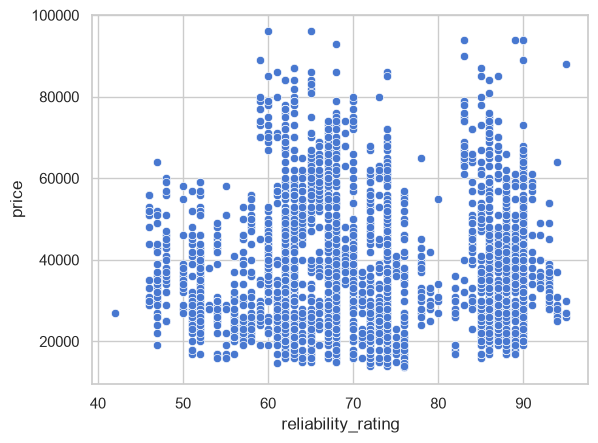

In [11]:
g1 = sns.scatterplot(
    data=df,
    x='reliability_rating',
    y='price'
)
plt.show()

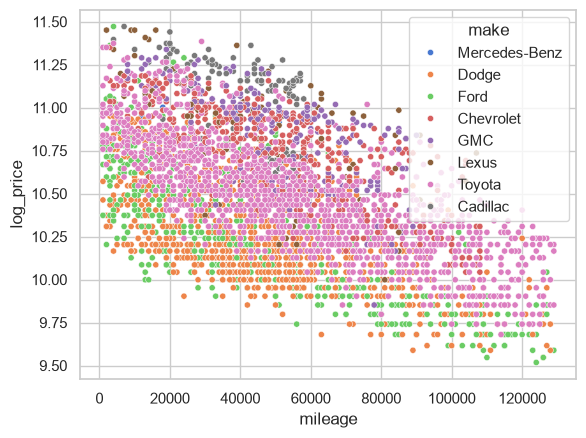

In [30]:
g1 = sns.scatterplot(
    data=df,
    x='mileage',
    y='price',
    hue="make",
    s=20
)

#g1 = sns.set_yscale('log')

plt.show()

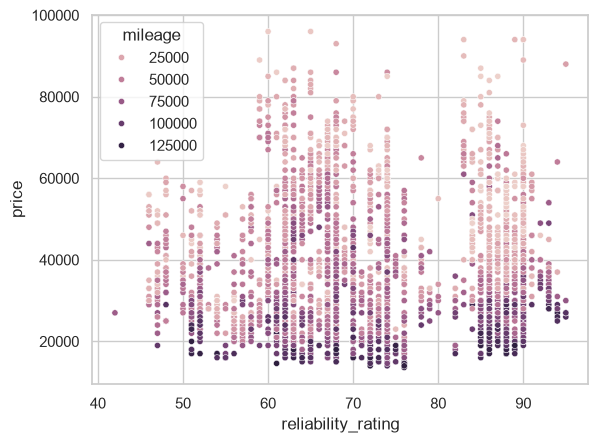

In [13]:
g1 = sns.scatterplot(
    data=df,
    x='reliability_rating',
    y='price',
    hue="mileage",
    s=20
)

#g1 = sns.set_yscale('log')

plt.show()

In [8]:
v8_muscle = df[
        (
            ((df['make'] == 'Dodge') & (df['model'] == 'Challenger') & (df['cylinders'] == 8)) |
            ((df['make'] == 'Ford') & (df['model'] == 'Mustang') & (df['cylinders'] == 8))
        ) & 
        #(~df['model'].str.contains('Shelby', case=False, na=False))&
        (df['horsepower']>400)&
        (df['horsepower']<500)&
        (df['mileage']>0)
    ].copy()

D:\R Working Directory\Used Car Analyser\.venv\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


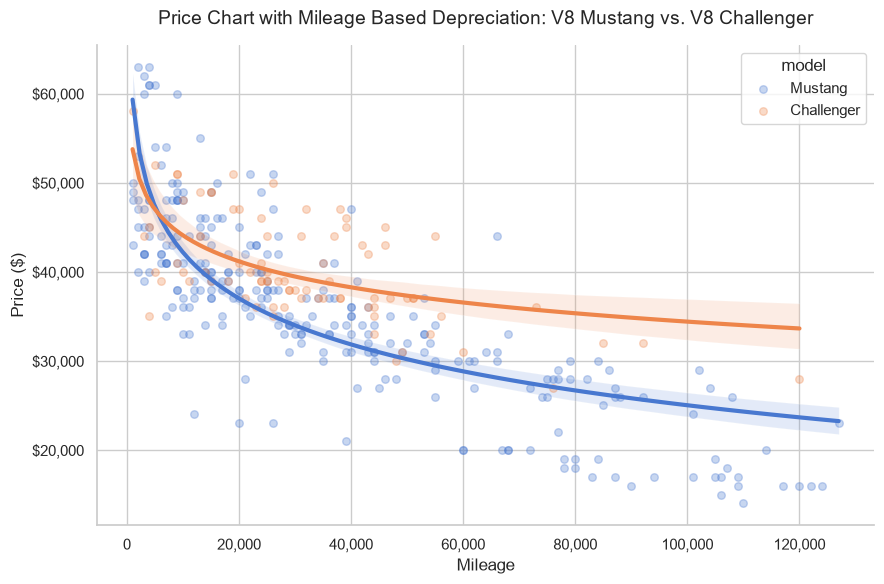

In [11]:
g1 = sns.lmplot(
        data=v8_muscle, 
        x='mileage', 
        y='price', 
        hue='model',
        #lowess=True, 
        logx=True,
        scatter_kws={'alpha': 0.3, 's': 30}, # Make points semi-transparent and smaller
        line_kws={'linewidth': 3},           # Make the line of best fit pop
        height=6, 
        aspect=1.5,
        legend_out=False
    )
g1.set_axis_labels('Mileage', 'Price ($)')
plt.title('Price Chart with Mileage Based Depreciation: V8 Mustang vs. V8 Challenger', pad=15, fontsize=14)
# Format axes with commas
g1.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
g1.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${format(int(y), ',')}"))
plt.tight_layout()
plt.show()

In [38]:
perf_cars = df[(df['accel']<4.5) & (df['fuel_economy']>0)]

perf_cars_agg = perf_cars.groupby('make_model').agg(
    n=('make_model','size'),
    price = ('price','median'),
    mileage = ('mileage','median'),
    qmile = ('qmile_time','mean'),
    quality = ('quality_rating','mean'),
    amenity = ('amenity_rating','mean'),
    reliability = ('reliability_rating','mean'),
    economy = ('fuel_economy','mean')
).reset_index()

print(perf_cars_agg.sort_values(by='qmile'))

              make_model    n    price  mileage      qmile    quality  \
8  Mercedes-Benz C63 AMG   13  54998.0  29000.0  12.053846  87.615385   
0       Dodge Challenger   82  38998.0  28500.0  12.331707  63.195122   
1          Dodge Charger   97  43998.0  26000.0  12.403093  66.360825   
4           Lexus IS 500    9  60998.0  25000.0  12.422222  86.555556   
3           Ford Mustang  280  37498.0  25000.0  12.475000  68.335714   
7             Lexus RC F    4  40998.0  70500.0  12.600000  85.750000   
2          Dodge Durango    7  48998.0  46000.0  12.685714  67.000000   
5           Lexus LC 500    9  80998.0  14000.0  12.800000  90.000000   
6           Lexus LS 500   11  41998.0  48000.0  12.800000  92.909091   

     amenity  reliability    economy  
8  83.923077    49.076923  18.615385  
0  51.036585    56.414634  13.231707  
1  57.144330    58.103093  13.896907  
4  80.666667    87.555556  18.000000  
3  62.960714    68.760714  14.939286  
7  75.750000    83.750000  16.00000

In [14]:
df_agg = df.groupby('make_model').agg(
    quality = ('quality_rating','mean'),
    amenity = ('amenity_rating','mean'),
    reliability = ('reliability_rating','mean'),
    economy = ('fuel_economy','mean'),
    n=('make_model','size'),
    mileage = ('mileage','median'),
    price = ('price','median')
    
).reset_index()

print(df_agg.sort_values(by=['reliability','quality'], ascending=[False,False]).head(n=10))


                 make_model    quality    amenity  reliability    economy  \
20      Toyota Land Cruiser  80.920000  66.840000    89.560000  15.200000   
17           Toyota 4Runner  67.159696  48.513308    89.228137  16.245247   
10             Lexus LC 500  90.000000  84.555556    87.666667  16.000000   
9              Lexus IS 500  86.555556  80.666667    87.555556  18.000000   
19        Toyota Highlander  76.296243  67.372832    87.426301  23.420520   
13             Lexus LX 570  85.235294  70.705882    86.882353  13.235294   
12             Lexus LS 500  93.000000  90.700000    86.250000  18.450000   
18  Toyota Grand Highlander  78.240741  73.259259    85.703704  24.037037   
21           Toyota Sequoia  74.230769  65.769231    85.320513  16.435897   
15               Lexus RC F  85.750000  75.750000    83.750000  16.000000   

      n  mileage    price  
20   25   9000.0  60998.0  
17  526  58000.0  37998.0  
10    9  14000.0  80998.0  
9     9  25000.0  60998.0  
19  692  540

In [15]:
print(df_agg[df_agg['price']<35000].sort_values(by=['reliability','quality'], ascending=[False,False]).head(n=10))

           make_model    quality    amenity  reliability    economy    n  \
19  Toyota Highlander  76.296243  67.372832    87.426301  23.420520  692   
11       Lexus LS 460  89.040000  83.880000    77.360000  17.280000   25   
6        Ford Mustang  68.145215  62.184818    68.764026  19.468647  606   
4       Dodge Charger  64.355641  58.022945    61.242830  17.713193  523   
3    Dodge Challenger  60.551913  48.751366    60.551913  16.956284  366   
5       Dodge Durango  66.586420  65.370370    59.191358  16.592593  162   

    mileage    price  
19  54000.0  30998.0  
11  69000.0  28998.0  
6   39000.0  26998.0  
4   45000.0  25998.0  
3   42000.0  26998.0  
5   44000.0  31998.0  


# Mileage Elasticity

The OLS model estimates that **each additional mile reduces price by ~0.0007%**.

Scaled to a **50,000-mile increase**, this equates to roughly **30% lower price**.

*Note: This is a rough estimate. The Durbin-Watson statistic (0.234) indicates severe autocorrelation — the residuals are not independent. The coefficient is directionally correct but the confidence intervals are likely wider than reported.*


In [16]:
x_vars = ['mileage']
x = df[x_vars]
x = sm.add_constant(x)
y = df['log_price']
lm = sm.OLS(y,x).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     1830.
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:03:54   Log-Likelihood:                -977.87
No. Observations:                3967   AIC:                             1960.
Df Residuals:                    3965   BIC:                             1972.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.8119      0.010   1115.740      0.0

In [17]:
params = lm.params
print("Percent change for each point of independent variables:\n")
transformed_coef = 100*(np.exp(params)-1)
for var,val in transformed_coef.items():
    if var=='const':
        continue
    print(f"{var}: {val:4f}%")

Percent change for each point of independent variables:

mileage: -0.000708%


In [18]:
beta_mileage = lm.params['mileage']
prop_change = 100*(np.exp(beta_mileage*50000)-1)
print("Average impact of 50,000 mile increase")
print(f"{prop_change}%")

Average impact of 50,000 mile increase
-29.80210476834647%


In [8]:
num_features = ['year', 'mileage', 'horsepower', 'torque', 'accel', 'quality_rating', 'reliability_rating','amenity_rating']
cat_features = ['make', 'model']
target = 'price'

df_model = df[num_features + cat_features + [target]]
# Drop rows with missing values in key columns
df_model = df_model.dropna(subset=num_features + [target])

# Encode categoricals (make and model)
df_encoded = pd.get_dummies(df_model, columns=cat_features, drop_first=True)


# Dummy columns (automatically named 'make_Ford', 'model_Mustang', etc.)
dummy_cols = [col for col in df_encoded.columns if col.startswith(('make_', 'model_'))]

# Combine them
feature_cols = num_features + dummy_cols

# Select features (X) and target (y)
X = df_encoded[feature_cols]
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Train XGBoost
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_cv = -cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
r2_cv   = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')

print("=== Cross Validation of Model ===")
print(f"RMSE: {rmse_cv.mean():.2f} ± {rmse_cv.std():.2f}")
print(f"R²:   {r2_cv.mean():.3f} ± {r2_cv.std():.3f}")

=== Cross Validation of Model ===
RMSE: 2484.26 ± 200.18
R²:   0.970 ± 0.004


In [10]:
# Evaluate on Test Set
y_pred_test = model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"=== XGBoost Model Performance (Test Set) ===")
print(f"R² Score: {test_r2:.3f}")
print(f"RMSE: ${test_rmse:,.0f}")

=== XGBoost Model Performance (Test Set) ===
R² Score: 0.973
RMSE: $2,424


# Feature Importance: What Drives Price?

The SHAP summary plot reveals the true hierarchy of pricing drivers:

1. **Torque** — The single most important feature. Buyers pay for twist.
2. **Mileage** — Condition matters more than almost anything else.
3. **Year** — Newer cars command a premium, but the effect diminishes over time.
4. **Horsepower** — Significant, but less than torque. Suggests buyers value twist over peak power.
5. **Acceleration** — The 0-60 time is a strong proxy for performance and drives price.

**Key Insight:** The top 5 features are all **engineering or condition** metrics. Brand (`make`) and model identity rank much lower. The "badge premium" exists but is secondary to what the car actually *is*.


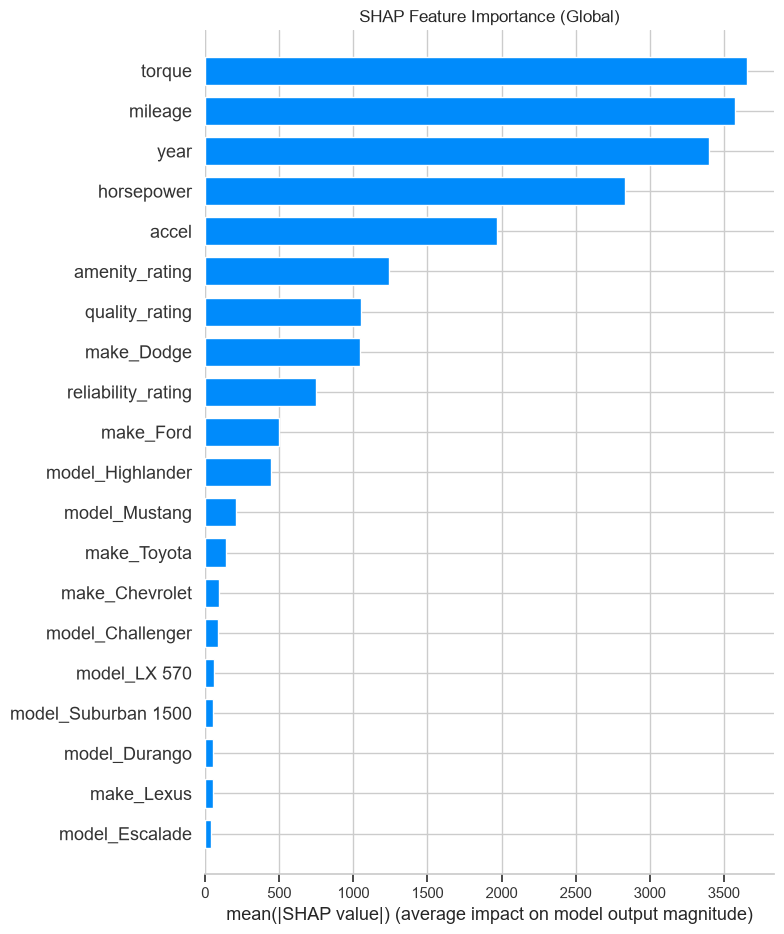

In [84]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot 1: SHAP Summary (Global Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

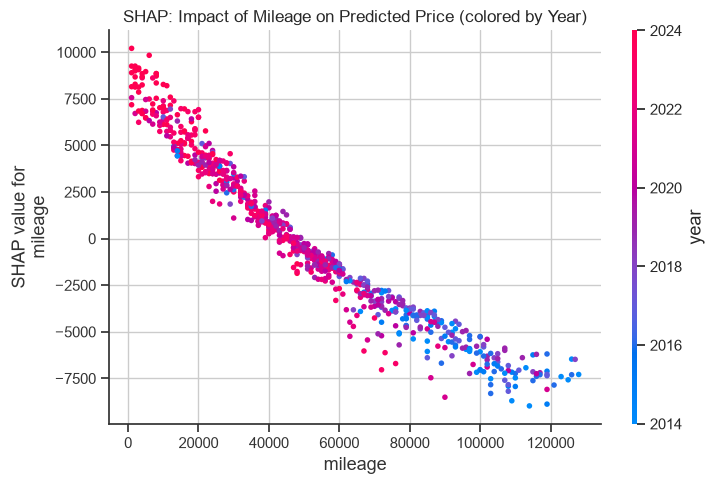

In [89]:
plt.figure(figsize=(10, 6))
shap.dependence_plot("mileage", shap_values, X_test, interaction_index="year", show=False)
plt.title("SHAP: Impact of Mileage on Predicted Price (colored by Year)")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

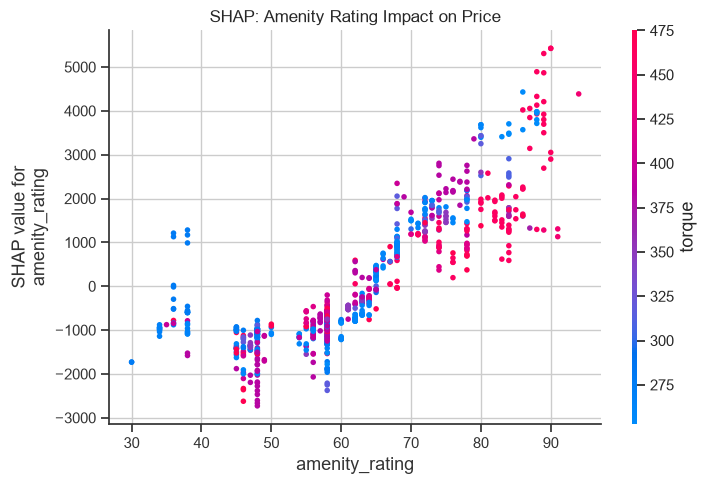

In [94]:
plt.figure(figsize=(10, 6))
shap.dependence_plot("amenity_rating", shap_values, X_test, show=False)
plt.title("SHAP: Amenity Rating Impact on Price")
plt.tight_layout()
plt.show()


In [11]:
# Predict on ALL data (not just test set) to get residuals for every listing
X_all = df_encoded[feature_cols]
df_model['predicted_price'] = model.predict(X_all)

# Calculate Residuals
# Positive residual = Underpriced (Good Deal)
# Negative residual = Overpriced (Bad Deal)
df_model['residual'] = df_model['price'] - df_model['predicted_price']
df_model['residual_pct'] = 100*(df_model['residual'] / df_model['price'])

# Merge back to the original dataframe df
# We merge on the index to ensure rows align correctly
df = df.merge(df_model[['predicted_price', 'residual', 'residual_pct']], left_index=True, right_index=True, how='left')

print("=== Sample of Residuals ===")
print(df[['make', 'model', 'trim', 'price', 'predicted_price', 'residual', 'residual_pct']].head(10))



=== Sample of Residuals ===
            make    model trim  price  predicted_price     residual  \
0  Mercedes-Benz  C63 AMG    -  63998     64820.359375  -822.359375   
1  Mercedes-Benz  C63 AMG    -  47998     48210.300781  -212.300781   
2  Mercedes-Benz  C63 AMG    -  33998     34594.074219  -596.074219   
3  Mercedes-Benz  C63 AMG    S  59998     57308.953125  2689.046875   
4  Mercedes-Benz  C63 AMG    S  45998     48255.566406 -2257.566406   
5  Mercedes-Benz  C63 AMG    S  55998     56444.707031  -446.707031   
6  Mercedes-Benz  C63 AMG    S  54998     54823.265625   174.734375   
7  Mercedes-Benz  C63 AMG    S  50998     51771.621094  -773.621094   
8  Mercedes-Benz  C63 AMG    S  57998     57464.417969   533.582031   
9  Mercedes-Benz  C63 AMG    S  42998     43917.339844  -919.339844   

   residual_pct  
0     -1.284977  
1     -0.442312  
2     -1.753263  
3      4.481894  
4     -4.907966  
5     -0.797720  
6      0.317710  
7     -1.516964  
8      0.920001  
9     -2.1

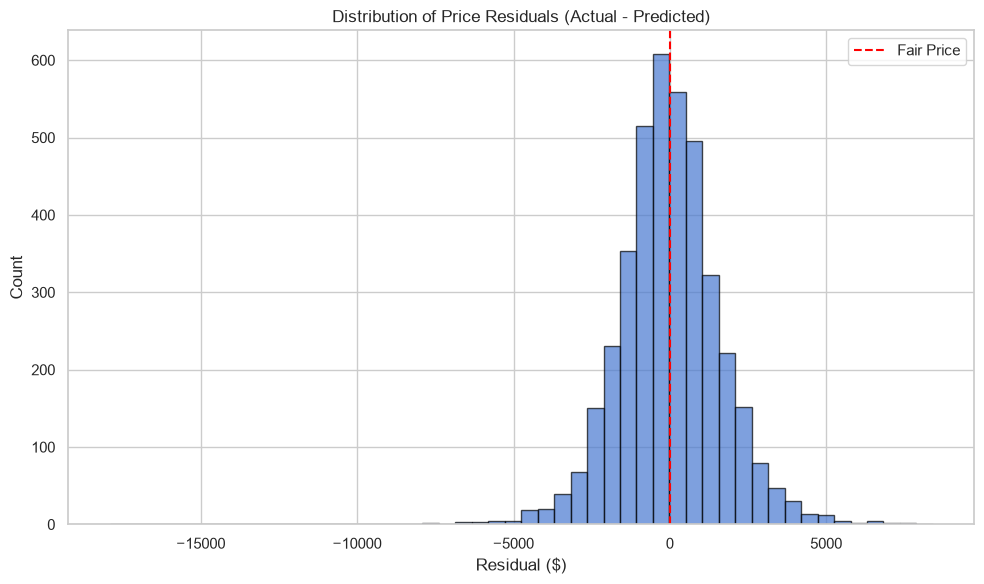

In [96]:
# Plot 1: Distribution of Residuals
plt.figure(figsize=(10, 6))
plt.hist(df['residual'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Fair Price')
plt.title("Distribution of Price Residuals (Actual - Predicted)")
plt.xlabel("Residual ($)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


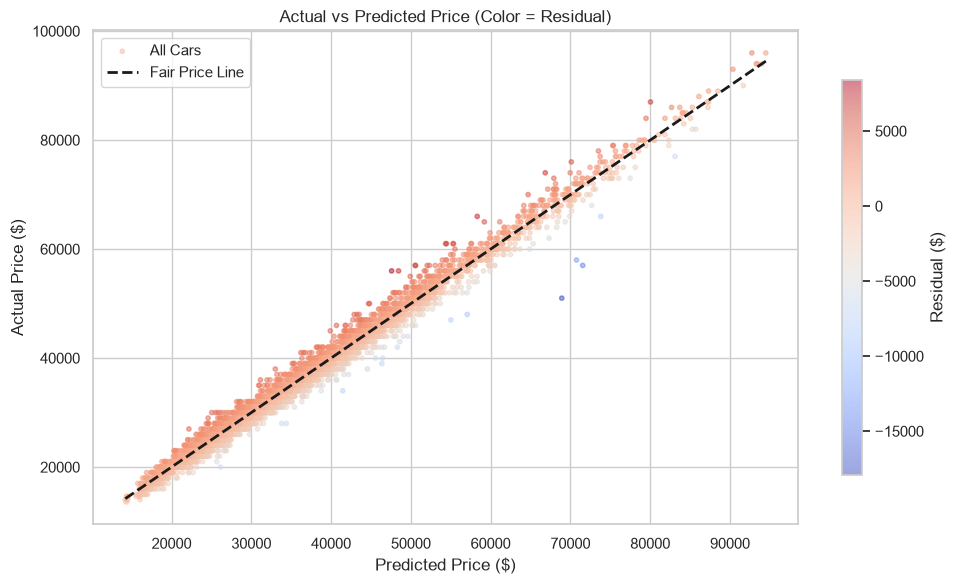

In [97]:
# Plot 2: Actual vs Predicted Price (with Residuals highlighted)
plt.figure(figsize=(10, 6))
# Scatter all cars
plt.scatter(df['predicted_price'], df['price'], c=df['residual'], cmap='coolwarm', alpha=0.5, s=10, label='All Cars')
plt.plot([df['predicted_price'].min(), df['predicted_price'].max()], 
         [df['predicted_price'].min(), df['predicted_price'].max()], 'k--', lw=2, label='Fair Price Line')
plt.colorbar(label='Residual ($)', shrink=0.8)
plt.xlabel("Predicted Price ($)")
plt.ylabel("Actual Price ($)")
plt.title("Actual vs Predicted Price (Color = Residual)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
def pareto_filter(df, maximize_cols, minimize_cols):
    """
    Remove dominated rows from a DataFrame.
    """
    # 1. Select only the columns we care about
    compare_cols = maximize_cols + minimize_cols
    
    # 2. Drop rows with NaN in any of the comparison columns
    df_clean = df[compare_cols].dropna()
    
    if df_clean.empty:
        return df.iloc[:0]

    # 3. Normalize each column to [0, 1]
    normalized = pd.DataFrame(index=df_clean.index)
    
    for col in maximize_cols:
        col_min = df_clean[col].min()
        col_max = df_clean[col].max()
        if col_max == col_min:
            normalized[col] = 0.5 
        else:
            normalized[col] = (df_clean[col] - col_min) / (col_max - col_min)
            
    for col in minimize_cols:
        col_min = df_clean[col].min()
        col_max = df_clean[col].max()
        if col_max == col_min:
            normalized[col] = 0.5
        else:
            # Invert: min value becomes 1, max value becomes 0
            normalized[col] = 1 - (df_clean[col] - col_min) / (col_max - col_min)
            
    # 4. Vectorized dominance check
    vals = normalized.values # Shape (N, K)
    n = len(vals)
    
    # Reshape for broadcasting: (N, 1, K) vs (1, N, K)
    # a_dominates_b[i, j] = True if row i dominates row j
    # Check if row i is >= row j on all cols
    ge = vals[:, np.newaxis, :] >= vals[np.newaxis, :, :]
    # Check if row i is > row j on at least one col
    gt = vals[:, np.newaxis, :] > vals[np.newaxis, :, :]
    
    # Dominance: ge is True for all cols AND gt is True for at least one col
    dominates = ge.all(axis=2) & gt.any(axis=2)
    
    # If any row dominates row j, mark j as dominated
    dominated = dominates.any(axis=0)
    
    # Return the NON-dominated rows from the ORIGINAL df
    # We need to map back to the original df index
    return df.loc[df_clean.index[~dominated]].copy()

In [12]:
# Define maximize/minimize columns
max_cols_df = ['reliability_rating', 'amenity_rating', 'quality_rating', 'residual_pct']
min_cols_df = ['price', 'mileage']

# Apply Pareto filter
df_pareto = pareto_filter(df, max_cols_df, min_cols_df)

print(f"=== Pareto Frontier ===")
print("Finding the highest quality, most equipped, most reliable cars for the lowest price with the lowest miles")
print(f"Original listings: {len(df)}")
print(f"Non-dominated listings: {len(df_pareto)}")
print(f"Removed {len(df) - len(df_pareto)} dominated listings")

# Sort by price to see cheapest first
df_pareto = df_pareto.sort_values('price')
print(df_pareto[['make', 'model', 'trim', 'year', 'price', 'mileage', 
                 'reliability_rating', 'quality_rating', 'amenity_rating']].head(20))

=== Pareto Frontier ===
Finding the highest quality, most equipped, most reliable cars for the lowest price with the lowest miles
Original listings: 3973
Non-dominated listings: 1199
Removed 2774 dominated listings
        make       model              trim  year  price  mileage  \
54      Ford     Mustang                 -  2014  13599   124000   
39     Dodge  Challenger               SXT  2014  13998   126000   
33      Ford     Mustang           Premium  2013  13998   110000   
65      Ford     Mustang                 -  2014  13998   126000   
186    Dodge     Charger                SE  2016  14599   111000   
57      Ford     Mustang                 -  2014  14599   109000   
58      Ford     Mustang                 -  2014  14599   123000   
44     Dodge     Charger                SE  2014  14599    89000   
150     Ford     Mustang  Ecoboost Premium  2015  14998   115000   
42     Dodge     Charger                SE  2014  14998    93000   
28      Ford     Mustang             

# Pareto Frontier: The Best Value Cars

We are looking for the most reliable, best equipped, best built car for cheap with low miles.

The Pareto filter reduced **3,973 listings** down to **61 non-dominated options**.

A car is "non-dominated" if there is no other car that is **cheaper AND has lower mileage AND has equal or better reliability**. In other words, these are the cars you cannot improve on one metric without worsening another.

**Observations:**
- **Toyota Highlander** and **4Runner** dominate the reliability end of the frontier.
- **Ford Mustang** and **Dodge Charger** dominate the low-price/high-performance end.


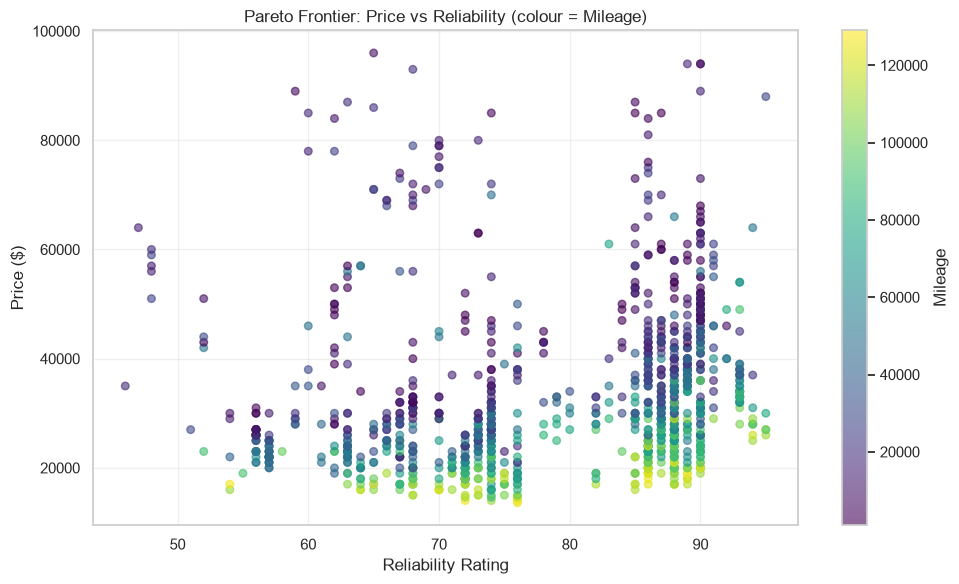

In [113]:
# Visualise the frontier
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_pareto['reliability_rating'], df_pareto['price'], 
                      c=df_pareto['mileage'], cmap='viridis', s=30, alpha=0.6, label='Pareto Front')
plt.colorbar(scatter, label='Mileage')
plt.xlabel('Reliability Rating')
plt.ylabel('Price ($)')
plt.title('Pareto Frontier: Price vs Reliability (colour = Mileage)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
def topsis(df, criteria, weights=None):
    """
    Multi-criteria TOPSIS ranking.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the criterion columns.
    criteria : list of tuples
        (column_name, 'max' or 'min')
        e.g. [('price', 'min'), ('reliability', 'max')]
    weights : list of float, optional
        Relative weights for each criterion. If None, equal weights.
    
    Returns
    -------
    df : pd.DataFrame with added columns:
        'score'   - TOPSIS closeness coefficient [0, 1]
        'rank'    - 1 = best
    """
    if weights is None:
        weights = np.ones(len(criteria))
    else:
        weights = np.array(weights)
    
    # Normalise (vector normalisation)
    normalised = df[[c[0] for c in criteria]].copy()
    for col, _ in criteria:
        col_vals = normalised[col].values.astype(float)
        norm = np.sqrt(np.sum(col_vals ** 2))
        if norm > 0:
            normalised[col] = col_vals / norm
    
    # Weight
    weighted = normalised * weights
    
    # Ideal and anti-ideal
    ideal = pd.Series({c[0]: weighted[c[0]].max() if c[1] == 'max' else weighted[c[0]].min()
                       for c in criteria})
    anti_ideal = pd.Series({c[0]: weighted[c[0]].min() if c[1] == 'max' else weighted[c[0]].max()
                            for c in criteria})
    
    # Distances
    dist_ideal = np.sqrt(((weighted - ideal) ** 2).sum(axis=1))
    dist_anti = np.sqrt(((weighted - anti_ideal) ** 2).sum(axis=1))
    
    # Closeness coefficient
    score = dist_anti / (dist_ideal + dist_anti)
    
    df = df.copy()
    df['score'] = score
    df['rank'] = df['score'].rank(ascending=False).astype(int)
    return df

# TOPSIS Ranking: Multi-Criteria Decision Making

TOPSIS ranks cars by their closeness to an "ideal" car (highest reliability, amenity, quality, residual_pct; lowest price, mileage).

**Top Picks:**
1. **Dodge Charger GT** — High residual_pct (underpriced relative to specs) and strong reliability.
2. **Toyota Highlander SE** — Best reliability score, though higher mileage.
3. **Ford Mustang GT** — Strong balance of reliability and value.

**Sensitivity:** When we equalise weights (removing the emphasis on reliability), the ranking shifts slightly. 


In [15]:
criteria_p1 = [
    ('reliability_rating', 'max'),
    ('amenity_rating', 'max'),
    ('quality_rating', 'max'),
    ('residual_pct','max'),
    ('price', 'min'),
    ('mileage', 'min'),
]

weights_p1 = [3, 1, 1, 2, 1, 1]

# Run TOPSIS on the Pareto set
df_pareto_topsis = topsis(df_pareto, criteria_p1, weights_p1)

print("=== PROBLEM 1: TOPSIS on Pareto Frontier ===")
print(df_pareto_topsis[['make', 'model', 'trim', 'year', 'price', 'mileage', 
                        'reliability_rating','amenity_rating', 'quality_rating', 'residual','residual_pct', 'score', 'rank']].sort_values('rank').head(20))



=== PROBLEM 1: TOPSIS on Pareto Frontier ===
           make       model                  trim  year  price  mileage  \
477       Dodge     Charger                    GT  2019  29998    28000   
2537     Toyota  Highlander                    SE  2019  29998    70000   
153        Ford     Mustang            GT Premium  2015  26998   104000   
1723      Lexus      LS 460                     L  2014  28998    85000   
2640  Chevrolet       Tahoe               Premier  2020  55998    35000   
1595       Ford     Mustang              Ecoboost  2024  35998    18000   
1199      Dodge     Charger                   SXT  2022  29998    22000   
3826     Toyota     4Runner               TRD Pro  2024  55998    48000   
1721      Lexus      LS 460                     -  2014  29998    66000   
419       Dodge  Challenger                    GT  2019  27998    60000   
2247     Toyota     4Runner               TRD Pro  2018  37998    96000   
483       Dodge     Charger               GT Plus  2019

**Note on residual_pct:** The residual captures how far a car's price deviates from the model's prediction. Given the model's RMSE of \\$2,424, residuals below this threshold should be treated as noise. The TOPSIS ranking prioritises cars with meaningful positive residuals (>~\$2,500) as potential deals, but these should be verified against actual market conditions.


In [16]:
# Sensitivity analysis: equal weights
weights_p1_rel = [1, 1, 1, 1, 1, 1]
df_pareto_topsis_rel = topsis(df_pareto, criteria_p1, weights_p1_rel)
print("\n--- Sensitivity: equal weightings ---")
print(df_pareto_topsis_rel[['make', 'model', 'trim', 'price', 'score', 'rank']].sort_values('rank').head(10))


--- Sensitivity: equal weightings ---
           make       model              trim  price     score  rank
477       Dodge     Charger                GT  29998  0.890068     1
1595       Ford     Mustang          Ecoboost  35998  0.875104     2
1199      Dodge     Charger               SXT  29998  0.864578     3
2537     Toyota  Highlander                SE  29998  0.852030     4
1721      Lexus      LS 460                 -  29998  0.848375     5
1723      Lexus      LS 460                 L  28998  0.846732     6
2640  Chevrolet       Tahoe           Premier  55998  0.843807     7
483       Dodge     Charger           GT Plus  27998  0.841684     8
957       Dodge     Durango           Citadel  34998  0.837904     9
392        Ford     Mustang  Ecoboost Premium  24998  0.837362    10
